<a href="https://colab.research.google.com/github/AleynaCifcibasi/Python-ile-Machine-Learning-al-malar-ve-projeleri/blob/main/Python_Oturum_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
X = 2 * np.random.rand(100,1)



In [3]:
y = 4 + 3 * X + np.random.randn(100,1) #Rastgele Gaussian (normal dağılım) hatası ekler.


In [4]:
X_b = np.c_[np.ones((100,1)),X]


###hiper parametreler


In [5]:
ögrenme_oranı = 0.1
n_iterations = 1000
veri_sayı = 100

###ağırlıklalrın belirlenmesi

In [6]:
weights = np.random.randn(2,1)

In [7]:
for iteration in range(n_iterations):
  gradients = 2/veri_sayı * X_b.T.dot(X_b.dot(weights) - y) # MSE'nin türevi ile gradyanı hesapla
  weights -= ögrenme_oranı * gradients # Ağırlıkları güncelle (Gradyan iniş adımı)

In [8]:
# Maliyet (kayıp) fonksiyonunu tanımlıyoruz
def compute_cost(X, y, weights):
    m = len(y)  # Veri setindeki örnek sayısı
    predictions = X.dot(weights)  # Modelin tahmin ettiği değerler
    cost = np.sum((predictions - y) ** 2) / (2 * m)  # Ortalama kare hata (MSE) hesaplanıyor
    return cost  # Kayıp değeri döndür

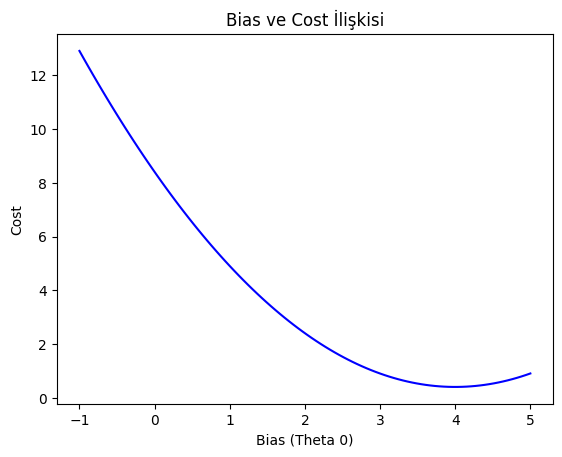

In [9]:
# Bias (θ₀) değerlerini test etmek için bir aralık oluşturuyoruz
weights_range = np.linspace(-1, 5, 100)  # -1 ile 5 arasında 100 farklı θ₀ değeri oluşturuluyor

# Her bias (θ₀) değeri için maliyet fonksiyonunu hesaplıyoruz
cost_values = [compute_cost(X_b, y, np.array([[w], [3]])) for w in weights_range]
# θ₁ (eğim) sabit olarak 3 alınırken, θ₀ farklı değerler alıyor

# Grafik çizdirme
plt.plot(weights_range, cost_values, 'b-')  # Mavi çizgi ile maliyet grafiğini çiziyoruz
plt.xlabel('Bias (Theta 0)')  # X ekseni etiketi (θ₀)
plt.ylabel('Cost')  # Y ekseni etiketi (MSE kayıp fonksiyonu)
plt.title('Bias ve Cost İlişkisi')  # Grafik başlığı
plt.show()  # Grafiği göster

#Yapay Sinir Ağları


In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [11]:
giris_verileri = np.array([[0],[1],[2],[3]])
cikis_verileri = np.array([0,2,4,6])

In [12]:
model = Sequential([
    Dense(units=1, input_shape=(1,))
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='sgd',loss='mean_squared_error')

In [14]:
model.fit(giris_verileri,cikis_verileri, epochs=1000,verbose=0)

In [15]:
test_verisi = np.array([[4],[5],[6]])

In [16]:
print("Tahmin sonucu : ",model.predict(test_verisi))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Tahmin sonucu :  [[ 7.9977164]
 [ 9.996492 ]
 [11.995268 ]]
